# Discretization and Binning
         - Qualitative
               - ordinal
               - nominal
         - Quantitative
                 - continues
                       - 
                 - Discrete

In [36]:
import pandas as pd

In [76]:
data = pd.read_excel('emp2.xlsx')

In [77]:
data

,Serial,Emp_ID,Designation,Department,Age,Salary
0,0,1101,Manager,Accounts,50,200000.000000
1,1,1107,Officer,IT,30,80000.000000
2,2,1203,Officer,HR,28,94173.913043
3,3,1005,Manager,HR,45,120000.000000
4,4,2123,Office Boy,Accounts,27,45000.000000
5,5,2451,Accountant,Production,34,100000.000000
6,6,1111,Accountant,Accounts,35,110000.000000
7,7,1001,Officer,IT,25,75000.000000
8,8,1234,Manager,IT,23,94173.913043
9,9,2156,Engineer,Production,45,89000.000000


In [78]:
data.Age

0     50
1     30
2     28
3     45
4     27
5     34
6     35
7     25
8     23
9     45
10    29
11    49
12    45
13    25
14    31
15    25
16    45
17    27
18    45
19    27
20    29
21    49
22    45
23    25
24    45
25    27
Name: Age, dtype: int64

In [79]:
data.Age.min()

23

In [80]:
data.Age.max()

50

In [81]:
data.Age.mean()

35.0

In [82]:
data.Age.var()

91.2

In [83]:
import matplotlib.pyplot as plt

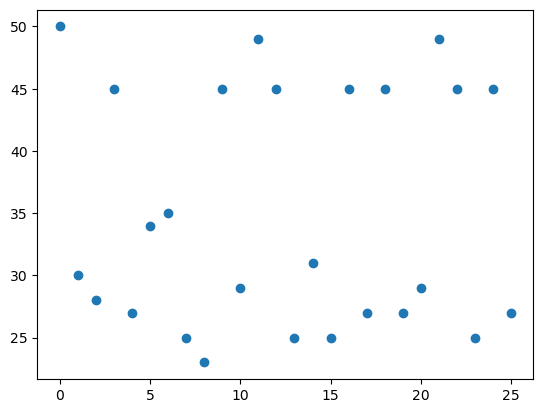

In [84]:
plt.scatter(y=data.Age, x=range(26))

In [85]:
data.Age - data.Age.mean()

0     15.0
1     -5.0
2     -7.0
3     10.0
4     -8.0
5     -1.0
6      0.0
7    -10.0
8    -12.0
9     10.0
10    -6.0
11    14.0
12    10.0
13   -10.0
14    -4.0
15   -10.0
16    10.0
17    -8.0
18    10.0
19    -8.0
20    -6.0
21    14.0
22    10.0
23   -10.0
24    10.0
25    -8.0
Name: Age, dtype: float64

In [86]:
data.Age.std()

9.549869109050658

In [87]:
data['AgeGroup']=pd.cut(data.Age, bins=[20,30,40,50], labels=['Young', 'Adult', 'Middle'])

In [88]:
data

,Serial,Emp_ID,Designation,Department,Age,Salary,AgeGroup
0,0,1101,Manager,Accounts,50,200000.000000,Middle
1,1,1107,Officer,IT,30,80000.000000,Young
2,2,1203,Officer,HR,28,94173.913043,Young
3,3,1005,Manager,HR,45,120000.000000,Middle
4,4,2123,Office Boy,Accounts,27,45000.000000,Young
5,5,2451,Accountant,Production,34,100000.000000,Adult
6,6,1111,Accountant,Accounts,35,110000.000000,Adult
7,7,1001,Officer,IT,25,75000.000000,Young
8,8,1234,Manager,IT,23,94173.913043,Young
9,9,2156,Engineer,Production,45,89000.000000,Middle


In [89]:
data.AgeGroup.value_counts()

AgeGroup
Young     13
Middle    10
Adult      3
Name: count, dtype: int64

In [90]:
data[data.Designation=='Accountant']

,Serial,Emp_ID,Designation,Department,Age,Salary,AgeGroup
5,5,2451,Accountant,Production,34,100000.0,Adult
6,6,1111,Accountant,Accounts,35,110000.0,Adult
11,11,3214,Accountant,Account,49,123000.0,Middle
21,21,3214,Accountant,Account,49,123000.0,Middle


# Computing Indicator/ Dummy Variables/ Data Encoding

In [91]:
ord('p')

112

In [92]:
for a in 'python':
    print(ord(a),end=',')

112,121,116,104,111,110,

In [93]:
for a in 'python':
    print(ord(a),end=',')
    print(bin(ord(a)))

112,0b1110000
121,0b1111001
116,0b1110100
104,0b1101000
111,0b1101111
110,0b1101110


In [94]:
data.Designation.unique()

array(['Manager', 'Officer', 'Office Boy', 'Accountant', 'Engineer'],
      dtype=object)

In [95]:
import warnings
warnings.filterwarnings('ignore')

In [96]:
data.Designation.replace(['Manager', 'Officer', 'Office Boy', 'Accountant', 'Engineer'], [0,1,2,3,4])

0     0
1     1
2     1
3     0
4     2
5     3
6     3
7     1
8     0
9     4
10    1
11    3
12    4
13    1
14    1
15    1
16    4
17    2
18    0
19    2
20    1
21    3
22    4
23    1
24    4
25    2
Name: Designation, dtype: int64

In [97]:
pd.get_dummies(data.Designation, dtype=int).head()

,Accountant,Engineer,Manager,Office Boy,Officer
0,0,0,1,0,0
1,0,0,0,0,1
2,0,0,0,0,1
3,0,0,1,0,0
4,0,0,0,1,0


In [98]:
pd.get_dummies(data.Department, dtype=int).head()

,Account,Accounts,HR,IT,Production
0,0,1,0,0,0
1,0,0,0,1,0
2,0,0,1,0,0
3,0,0,1,0,0
4,0,1,0,0,0


In [99]:
pd.get_dummies(data.Department, dtype=int)

,Account,Accounts,HR,IT,Production
0,0,1,0,0,0
1,0,0,0,1,0
2,0,0,1,0,0
3,0,0,1,0,0
4,0,1,0,0,0
5,0,0,0,0,1
6,0,1,0,0,0
7,0,0,0,1,0
8,0,0,0,1,0
9,0,0,0,0,1


# Data Wrangling: Join, Combine and Reshape

#### Combinig and Merging Dataset

In [113]:
data0 = pd.read_excel('test_data2.xlsx', sheet_name=0)
data1 = pd.read_excel('test_data2.xlsx', sheet_name=1)
data2 = pd.read_excel('test_data2.xlsx', sheet_name=2)

In [114]:
data0

,sales_man_id,sales_man_name,sales_man_city,product_id,manager
0,1,Asad,Karachi,123,Jawed
1,2,Sumair,Lahore,123,Jawed
2,3,Farjad,Karachi,145,Najam
3,4,Hassan,Lahore,567,Najam
4,5,Nasir,Hyderabad,234,Jawed
5,6,Kashif,Hyderabad,234,Faisal
6,7,Sana,Lahore,567,Faisal
7,8,Fatima,Karachi,345,Najam
8,9,Abdullah,Karachi,123,Faisal


In [115]:
data1

,sales_man_id,sales_man_name,sales_man_city,product_id,manager,Experience
0,1,Ahmed,Karachi,123,Jawed,2
1,22,Umer,Lahore,123,Jawed,3
2,33,Huzaifa,Karachi,145,Najam,4
3,4,Hassan,Lahore,567,Najam,5
4,55,Hussain,Hyderabad,234,Jawed,6
5,66,Ali,Hyderabad,234,Faisal,7
6,77,Sadaf,Lahore,567,Faisal,8
7,88,Kiran,Karachi,345,Najam,9
8,99,Ali,Karachi,123,Faisal,1
9,101,Asad,Hyderabad,432,Jawed,4


In [116]:
data2

,sales_man_id,sales_man_name,Region,Sales,Amount
0,2,Sumair,A,100,100000
1,5,Nasir,B,300,450000
2,7,Sana,C,234,125000
3,23,Sana,D,231,652000
4,45,Fatima,E,324,145000
5,1,Asad,F,123,825000
6,9,Abdullah,G,129,125000
7,56,Almas,H,345,325600
8,4,Hassan,I,400,895200


In [117]:
pd.concat([data0,data1],ignore_index=True)

,sales_man_id,sales_man_name,sales_man_city,product_id,manager,Experience
0,1,Asad,Karachi,123,Jawed,NaN
1,2,Sumair,Lahore,123,Jawed,NaN
2,3,Farjad,Karachi,145,Najam,NaN
3,4,Hassan,Lahore,567,Najam,NaN
4,5,Nasir,Hyderabad,234,Jawed,NaN
5,6,Kashif,Hyderabad,234,Faisal,NaN
6,7,Sana,Lahore,567,Faisal,NaN
7,8,Fatima,Karachi,345,Najam,NaN
8,9,Abdullah,Karachi,123,Faisal,NaN
9,1,Ahmed,Karachi,123,Jawed,2.0


# Merging : Joins

In [118]:
pd.merge(data0,data2,how='inner',on='sales_man_id')

,sales_man_id,sales_man_name_x,sales_man_city,product_id,manager,sales_man_name_y,Region,Sales,Amount
0,1,Asad,Karachi,123,Jawed,Asad,F,123,825000
1,2,Sumair,Lahore,123,Jawed,Sumair,A,100,100000
2,4,Hassan,Lahore,567,Najam,Hassan,I,400,895200
3,5,Nasir,Hyderabad,234,Jawed,Nasir,B,300,450000
4,7,Sana,Lahore,567,Faisal,Sana,C,234,125000
5,9,Abdullah,Karachi,123,Faisal,Abdullah,G,129,125000


In [119]:
pd.merge(data0,data1, how='outer', on='sales_man_id')

,sales_man_id,sales_man_name_x,sales_man_city_x,product_id_x,manager_x,sales_man_name_y,sales_man_city_y,product_id_y,manager_y,Experience
0,1,Asad,Karachi,123.0,Jawed,Ahmed,Karachi,123.0,Jawed,2.0
1,2,Sumair,Lahore,123.0,Jawed,NaN,NaN,NaN,NaN,NaN
2,3,Farjad,Karachi,145.0,Najam,NaN,NaN,NaN,NaN,NaN
3,4,Hassan,Lahore,567.0,Najam,Hassan,Lahore,567.0,Najam,5.0
4,5,Nasir,Hyderabad,234.0,Jawed,NaN,NaN,NaN,NaN,NaN
5,6,Kashif,Hyderabad,234.0,Faisal,NaN,NaN,NaN,NaN,NaN
6,7,Sana,Lahore,567.0,Faisal,NaN,NaN,NaN,NaN,NaN
7,8,Fatima,Karachi,345.0,Najam,NaN,NaN,NaN,NaN,NaN
8,9,Abdullah,Karachi,123.0,Faisal,NaN,NaN,NaN,NaN,NaN
9,22,NaN,NaN,NaN,NaN,Umer,Lahore,123.0,Jawed,3.0


In [120]:
pd.merge(data0,data1, how='left', on='sales_man_id')

,sales_man_id,sales_man_name_x,sales_man_city_x,product_id_x,manager_x,sales_man_name_y,sales_man_city_y,product_id_y,manager_y,Experience
0,1,Asad,Karachi,123,Jawed,Ahmed,Karachi,123.0,Jawed,2.0
1,2,Sumair,Lahore,123,Jawed,NaN,NaN,NaN,NaN,NaN
2,3,Farjad,Karachi,145,Najam,NaN,NaN,NaN,NaN,NaN
3,4,Hassan,Lahore,567,Najam,Hassan,Lahore,567.0,Najam,5.0
4,5,Nasir,Hyderabad,234,Jawed,NaN,NaN,NaN,NaN,NaN
5,6,Kashif,Hyderabad,234,Faisal,NaN,NaN,NaN,NaN,NaN
6,7,Sana,Lahore,567,Faisal,NaN,NaN,NaN,NaN,NaN
7,8,Fatima,Karachi,345,Najam,NaN,NaN,NaN,NaN,NaN
8,9,Abdullah,Karachi,123,Faisal,NaN,NaN,NaN,NaN,NaN


In [121]:
pd.merge(data0,data1, how='right', on='sales_man_id').drop(['sales_man_name_y','sales_man_city_y'], axis=1)

,sales_man_id,sales_man_name_x,sales_man_city_x,product_id_x,manager_x,product_id_y,manager_y,Experience
0,1,Asad,Karachi,123.0,Jawed,123,Jawed,2
1,22,NaN,NaN,NaN,NaN,123,Jawed,3
2,33,NaN,NaN,NaN,NaN,145,Najam,4
3,4,Hassan,Lahore,567.0,Najam,567,Najam,5
4,55,NaN,NaN,NaN,NaN,234,Jawed,6
5,66,NaN,NaN,NaN,NaN,234,Faisal,7
6,77,NaN,NaN,NaN,NaN,567,Faisal,8
7,88,NaN,NaN,NaN,NaN,345,Najam,9
8,99,NaN,NaN,NaN,NaN,123,Faisal,1
9,101,NaN,NaN,NaN,NaN,432,Jawed,4


In [122]:
pd.merge(data0,data1, how='right', on='sales_man_id')

,sales_man_id,sales_man_name_x,sales_man_city_x,product_id_x,manager_x,sales_man_name_y,sales_man_city_y,product_id_y,manager_y,Experience
0,1,Asad,Karachi,123.0,Jawed,Ahmed,Karachi,123,Jawed,2
1,22,NaN,NaN,NaN,NaN,Umer,Lahore,123,Jawed,3
2,33,NaN,NaN,NaN,NaN,Huzaifa,Karachi,145,Najam,4
3,4,Hassan,Lahore,567.0,Najam,Hassan,Lahore,567,Najam,5
4,55,NaN,NaN,NaN,NaN,Hussain,Hyderabad,234,Jawed,6
5,66,NaN,NaN,NaN,NaN,Ali,Hyderabad,234,Faisal,7
6,77,NaN,NaN,NaN,NaN,Sadaf,Lahore,567,Faisal,8
7,88,NaN,NaN,NaN,NaN,Kiran,Karachi,345,Najam,9
8,99,NaN,NaN,NaN,NaN,Ali,Karachi,123,Faisal,1
9,101,NaN,NaN,NaN,NaN,Asad,Hyderabad,432,Jawed,4


In [123]:
pd.merge(data0,data2, how='right', on='sales_man_id')

,sales_man_id,sales_man_name_x,sales_man_city,product_id,manager,sales_man_name_y,Region,Sales,Amount
0,2,Sumair,Lahore,123.0,Jawed,Sumair,A,100,100000
1,5,Nasir,Hyderabad,234.0,Jawed,Nasir,B,300,450000
2,7,Sana,Lahore,567.0,Faisal,Sana,C,234,125000
3,23,NaN,NaN,NaN,NaN,Sana,D,231,652000
4,45,NaN,NaN,NaN,NaN,Fatima,E,324,145000
5,1,Asad,Karachi,123.0,Jawed,Asad,F,123,825000
6,9,Abdullah,Karachi,123.0,Faisal,Abdullah,G,129,125000
7,56,NaN,NaN,NaN,NaN,Almas,H,345,325600
8,4,Hassan,Lahore,567.0,Najam,Hassan,I,400,895200
